# Feature Engineering 05 (Ensamblado, IV y selección)

## Resumen

Aquí van las tres tablas auxiliares para los 307.492 clientes de la población de modelado, y decido qué columnas llegan al modelo. La matriz pasa de 101 a 180 columnas sin ganar ni perder ninguna fila. Todo lo que se mide contra el default se mide solo sobre los 245.993 clientes de entrenamiento, y al final quedan 163 columnas después de imputar, codificar y seleccionar.

Lo que gobierna toda la lectura es que la ausencia no significa lo mismo en cada tabla. Quien no aparece en el buró tiene un 10,17% de default frente al 7,72% de quien sí, y quien nunca ha solicitado un crédito previo, un 5,93% frente al 8,19%. Por eso, cada tabla lleva su bandera de presencia y, por ello, el IV de una columna se lee sin ella. En `bureau`, casi todo el IV marginal se explica por la señal de no aparecer: `HAS_BUREAU_FINANCIAL_DETAIL` pasa de 0,0126 a 0,0005. En `bureau_balance` pasa al revés: con un dato solo para el 30% de los clientes, la señal repartida entre todos estaba diluida más de tres veces y, medida entre quienes tienen histórico `BB_MONTHS_TOTAL`, sube de 0,0124 a 0,0413.

Con un corte de 0,02 de IV, llegan 9 de las 41 candidatas, aunque solo 8 acaban en la matriz: `PREV_REFUSED_COUNT` (0,0463), `BB_MONTHS_TOTAL`, `BB_TRAJECTORY`, `BB_DPD_MONTHS_COUNT`, `BUREAU_DAYS_CREDIT_ENDDATE_MAX` (0,0293), y `WALLSMATERIAL_MODE`, `EMERGENCYSTATE_MODE` y `HOUSETYPE_MODE` del bloque de edificio; `BUREAU_CLOSED_COUNT` también llega, pero pierde frente a `BB_MONTHS_TOTAL`, con quien se solapa (r=0,80). Otras 21 columnas salen por motivos establecidos antes de mirar ese IV. En la redundancia entre tablas, la mora de `bureau` queda absorbida por `BB_OVERDUE_UNION`. `EXT_SOURCE_3`, que es un score de buró, ya lleva dentro buena parte de la mora y de la actividad del buró: de las 13 columnas que se mueven con él, solo 5 conservan 0,02 de IV por encima. Y `BUILDING_INFO_COUNT` no dice más que si hay algún dato del edificio. Veinte columnas quedan protegidas por su papel y no por su IV: las banderas de presencia, las variables de control y las dos banderas raras de señal severa.

Tres cosas para leer lo anterior. El corte es estable: las 6 columnas que caen entre 0,015 y 0,025 de IV quedan del mismo lado en 14 o 15 de las 15 particiones del entrenamiento, o en 0 o 1 si están por debajo. Las 20 cifras de control de cada tabla cuadran con el análisis exploratorio, y las diferencias se explican por los 19 clientes que quita la limpieza. Tanto los cortes como la selección están definidos sobre el entrenamiento completo, así que en la validación cruzada del modelado cada partición heredará las mismas colas de conteo, que no son estables entre particiones. Queda por decidir allí si se reeligen en cada una.

### Índice

- 1. Cuánto historial tiene cada cliente
- 2. Cuánto aporta cada candidata
- 3. Las decisiones que esperaban al IV
- 4. Cuando dos columnas dicen lo mismo
- 5. Qué acaba entrando al modelo
- 6. Cuadrando las cifras con el EDA

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import pandas as pd

from src.config import ruta
from src.data.loader import load_table
from src.features.build_features import (
    FICHEROS_DATOS,
    NOMBRE_FICHERO_PIPELINE,
    cargar_cortes,
    ensamblar_auxiliares,
    informe_reconciliacion,
    matriz_de_features,
    preparar_application,
)
from src.features.iv import (
    informe_building_info,
    informe_incremental_ext3,
    informe_iv,
    informe_mora_activa,
    informe_solo_vivas,
    informe_tripartita_mora,
    tramos,
)
from src.features.params import valor
from src.features.selection import (
    PRESENCIA_DE_TABLA,
    columnas_protegidas,
    informe_redundancia,
    pares_redundantes,
)
from src.features.split import cargar_split, solo_train

COLOR_PRESENTE, COLOR_NULO = "mediumseagreen", "orange"

### 1. Cuánto historial tiene cada cliente

In [2]:
split = cargar_split()
base = preparar_application()
bureau = load_table("bureau", reduce_memory=False)
bb = load_table("bureau_balance")
prev = load_table("previous_application", reduce_memory=False)

cargar_cortes(split)  # los ocho cortes refijados sobre train, leídos y no recalculados
ensamblada = ensamblar_auxiliares(base, bureau, bb, prev)
train = solo_train(ensamblada.merge(split[["SK_ID_CURR", "split"]], on="SK_ID_CURR"), split)

print(f"tabla principal: {base.shape[0]:,} filas y {base.shape[1]} columnas".replace(",", "."))
print(f"ensamblada:      {ensamblada.shape[0]:,} filas y {ensamblada.shape[1]} columnas".replace(",", "."))
print(f"train:           {len(train):,} clientes".replace(",", "."))

tabla principal: 307.492 filas y 101 columnas
ensamblada:      307.492 filas y 180 columnas
train:           245.993 clientes


In [3]:
presencia = PRESENCIA_DE_TABLA
cobertura = pd.DataFrame(
    {tabla: ensamblada[col].value_counts().reindex([1, 0], fill_value=0) for tabla, col in presencia.items()}
).T.set_axis(["con historial", "sin historial"], axis=1)
cobertura["% con"] = (cobertura["con historial"] / len(ensamblada) * 100).round(2)
cobertura

,con historial,sin historial,% con
bureau,263475,44017,85.69
bureau_balance,92220,215272,29.99
previous_application,291041,16451,94.65


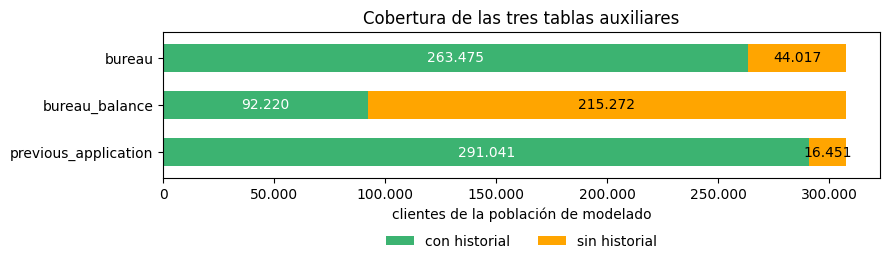

In [4]:
conteos = cobertura[["con historial", "sin historial"]]
fig, ax = plt.subplots(figsize=(9, 3))
conteos.iloc[::-1].plot.barh(stacked=True, color=[COLOR_PRESENTE, COLOR_NULO], ax=ax, width=0.6)
for fila, (con, sin) in enumerate(conteos.iloc[::-1].itertuples(index=False)):
    ax.text(con / 2, fila, f"{con:,}".replace(",", "."), ha="center", va="center", color="white")
    ax.text(con + sin / 2, fila, f"{sin:,}".replace(",", "."), ha="center", va="center")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
ax.set(xlabel="clientes de la población de modelado", ylabel="", title="Cobertura de las tres tablas auxiliares")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

In [5]:
tasas = pd.concat(
    {tabla: train.groupby(presencia[tabla])["TARGET"].agg(tasa="mean", n="size") for tabla in ("bureau", "previous_application")}
).rename(index={1: "con historial", 0: "sin historial"}, level=1).rename_axis(["tabla", "grupo"])
tasas["tasa"] = (tasas["tasa"] * 100).round(2)
tasas

tasa       n
tabla                grupo                       
bureau               sin historial  10.17   35118
                     con historial   7.72  210875
previous_application sin historial   5.93   13200
                     con historial   8.19  232793

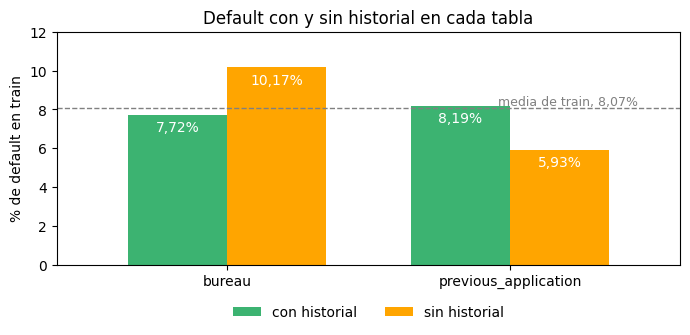

In [6]:
media = train["TARGET"].mean() * 100
fig, ax = plt.subplots(figsize=(7, 3.5))
tasas["tasa"].unstack()[["con historial", "sin historial"]].plot.bar(
    color=[COLOR_PRESENTE, COLOR_NULO], ax=ax, rot=0, width=0.7
)
for barra in ax.patches:
    ax.annotate(f"{barra.get_height():.2f}%".replace(".", ","), (barra.get_x() + barra.get_width() / 2, barra.get_height() - 0.3), ha="center", va="top", color="white")
ax.axhline(media, color="grey", ls="--", lw=1)
ax.text(1.45, media, f"media de train, {media:.2f}%".replace(".", ","), ha="right", va="bottom", fontsize=9, color="grey")
ax.set(xlabel="", ylabel="% de default en train", ylim=(0, 12), title="Default con y sin historial en cada tabla")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

Al unir las tres tablas auxiliares a los 307.492 clientes de la tabla principal, la matriz pasa de 101 a 180 columnas sin perder ni ganar filas. La cobertura es muy desigual: `previous_application` llega al 94,65% de los clientes (291.041), `bureau` al 85,69% (263.475) y `bureau_balance` solo al 29,99% (92.220). Esto se debe a que el historial mensual cuelga de los créditos del buró y solo una parte de ellos se reporta.

Lo que determina cómo se trata un hueco es el signo del grupo sin historial, y este no es el mismo en cada tabla. Entre los 245.993 clientes de entrenamiento, quienes no aparecen en el buró tienen un 10,17% de default (35.118 clientes), frente al 7,72% de quienes sí aparecen. Quien nunca ha solicitado un crédito previo tiene un 5,93% (13.200), frente al 8,19%. Las cuatro cifras reproducen las que medí sobre la tabla entera antes de separar el entrenamiento: 10,12% y 7,73% en el buró, y 5,96% y 8,19% en las solicitudes previas. Así que el signo no depende de la partición. Rellenar con cero todas las ausencias, por igual, taparía el riesgo en una tabla y lo inflaría en la otra. Por eso cada tabla lleva su bandera de presencia, que conserva ese signo aunque el hueco se rellene después.

### 2. Cuánto aporta cada candidata

In [7]:
min_iv = valor("min_iv")
min_iv_texto = f"min_iv ({min_iv:.2f})".replace(".", ",")
iv = informe_iv(train)
print(f"{len(iv)} candidatas, {iv['iv_sin_presencia'].notna().sum()} con tabla auxiliar detrás")
print(f"llegan a min_iv ({min_iv:.2f}): {iv['llega'].sum()}".replace(".", ","))
iv[["fuente", "n", "iv", "iv_sin_presencia", "iv_lectura", "llega"]].sort_values("iv_lectura", ascending=False).round(4)

38 candidatas, 23 con tabla auxiliar detrás
llegan a min_iv (0,02): 5


,fuente,n,iv,iv_sin_presencia,iv_lectura,llega
feature,,,,,,
BUREAU_DAYS_CREDIT_ENDDATE_MAX,receta de bureau,200211,0.0395,0.0282,0.0282,True
WALLSMATERIAL_MODE,bloque edificio,121182,0.0268,NaN,0.0268,True
EMERGENCYSTATE_MODE,bloque edificio,129617,0.0236,NaN,0.0236,True
HOUSETYPE_MODE,bloque edificio,122792,0.0215,NaN,0.0215,True
BUILDING_INFO_COUNT,bloque edificio,245993,0.0212,NaN,0.0212,True
PREV_RELACION_CORTA_ACTIVA,COLUMNAS_SIN_RECETA,232793,0.0230,0.0175,0.0175,False
NAME_HOUSING_TYPE,"selection.py, vivienda",245993,0.0155,NaN,0.0155,False
PREV_EARLY_HOUR_RATIO,receta de previous_application,232793,0.0193,0.0139,0.0139,False
LIVE_CITY_NOT_WORK_CITY,"selection.py, pendiente de IV",245993,0.0138,NaN,0.0138,False


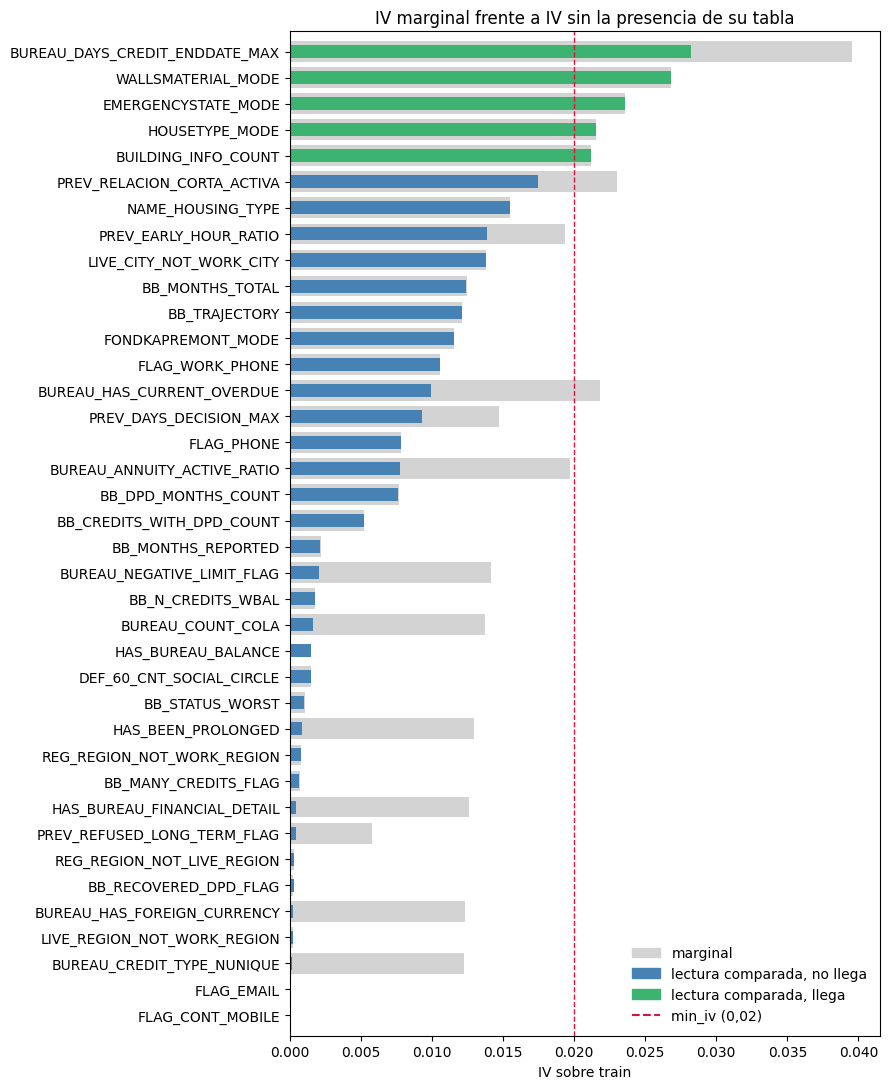

In [8]:
orden = iv.sort_values("iv_lectura").index
fig, ax = plt.subplots(figsize=(9, 11))
ax.barh(orden, iv.loc[orden, "iv"], color="lightgrey")
ax.barh(orden, iv.loc[orden, "iv_lectura"], height=0.5, color=iv.loc[orden, "llega"].map({True: COLOR_PRESENTE, False: "steelblue"}))
ax.axvline(min_iv, color="crimson", ls="--", lw=1)
ax.set(xlabel="IV sobre train", title="IV marginal frente a IV sin la presencia de su tabla")
ax.legend(
    handles=[Patch(color="lightgrey", label="marginal"), Patch(color="steelblue", label="lectura comparada, no llega"),
             Patch(color=COLOR_PRESENTE, label="lectura comparada, llega"), plt.Line2D([], [], color="crimson", ls="--", label=min_iv_texto)],
    loc="lower right", frameon=False,
)
ax.margins(y=0.01)
plt.tight_layout()
plt.show()

Antes de decidir nada con el IV, fijé qué columnas lo esperaban: 38 candidatas en total. Son las que en el EDA dejé explícitamente para el IV, las del bloque edificio, las que no tienen receta con la que compararse, los cuatro efectos que no se distinguían de cero y las dos banderas raras. El corte es un IV de 0,02 sobre los 245.993 clientes de entrenamiento, y solo lo pasan 5.

Lo que determina la lectura es de dónde proviene la señal. En las 23 candidatas obtenidas de una tabla auxiliar, el IV marginal combina dos cosas: lo que dice la columna y lo que indica si se tiene o no historial en esa tabla. Esto último el modelo ya lo recibe por la bandera de presencia, así que las comparo sin ella. En `bureau` la diferencia es enorme: `HAS_BUREAU_FINANCIAL_DETAIL` pasa de 0,0126 a 0,0005, `BUREAU_CREDIT_TYPE_NUNIQUE` de 0,0123 a 0,0001 y `BUREAU_NEGATIVE_LIMIT_FLAG` de 0,0141 a 0,0020. Casi todo su IV era la señal prestada de no aparecer en el buró, en el grupo del 10,17% de default. De las tres que pasaban el corte con el marginal solo lo sostiene `BUREAU_DAYS_CREDIT_ENDDATE_MAX` (de 0,0395 a 0,0282). `BUREAU_HAS_CURRENT_OVERDUE` (de 0,0218 a 0,0099) y `PREV_RELACION_CORTA_ACTIVA` (de 0,0230 a 0,0175) se mantienen por debajo.

Las otras cuatro que llegan son del bloque edificio y no tienen tabla auxiliar detrás: `WALLSMATERIAL_MODE` (0,0268), `EMERGENCYSTATE_MODE` (0,0236), `HOUSETYPE_MODE` (0,0215) y `BUILDING_INFO_COUNT` (0,0212). En la última, la sospecha es la misma, pero con otra forma: contar cuántos campos del edificio tiene informados un cliente puede estar repitiendo lo que ya dice tener alguno o ninguno.

`bureau_balance` se comporta al revés que `bureau`: sus columnas apenas pierden al quitar la presencia (`BB_MONTHS_TOTAL` pasa de 0,0125 a 0,0124), porque tener un histórico mensual casi no separa el riesgo (`HAS_BUREAU_BALANCE` tiene un IV marginal de 0,0000). Su IV es bajo por otro motivo: se reparte entre todos los clientes, aunque solo el 29,99% tiene datos. Lo retomo al fijar la selección final, en la que la lectura pasa a realizarse dentro de la población de cada tabla. Las dos banderas raras, `BUREAU_NEGATIVE_LIMIT_FLAG` y `PREV_REFUSED_LONG_TERM_FLAG` (0,0020 y 0,0004), no se descartan por este IV bajo: se quedan protegidas, con la decisión sostenida sobre el efecto que ya medí con su n.

### 3. Las decisiones que esperaban al IV

In [9]:
informe_mora_activa(train).round(4)

,n,n_marcados,iv_sin_presencia
BUREAU_HAS_CURRENT_OVERDUE,210875.0,2688.0,0.0099
BUREAU_CURRENT_OVERDUE_SUM > 0,210848.0,2687.0,0.0099


In [10]:
tripartita = informe_tripartita_mora(train)
tripartita.round(4)

,n,tasa,iv,llega
con_mora,57927.0,0.0955,NaN,NaN
reportada_cero,90085.0,0.0679,NaN,NaN
sin_reportar,62863.0,0.0738,NaN,NaN
union,NaN,NaN,0.0234,NaN
tripartita,NaN,NaN,0.0247,NaN
incremental_sobre_union,NaN,NaN,0.0014,False


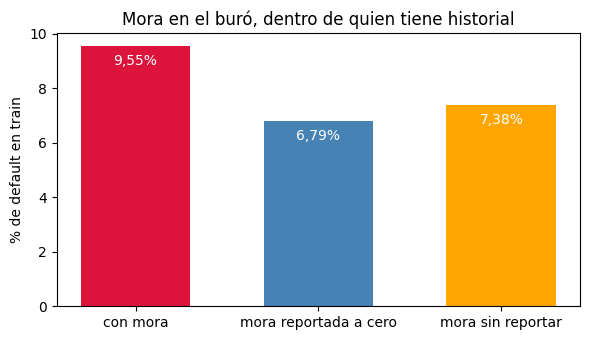

In [11]:
niveles = tripartita.loc[["con_mora", "reportada_cero", "sin_reportar"], "tasa"] * 100
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(["con mora", "mora reportada a cero", "mora sin reportar"], niveles, color=["crimson", "steelblue", COLOR_NULO], width=0.6)
for x, tasa in enumerate(niveles):
    ax.text(x, tasa - 0.3, f"{tasa:.2f}%".replace(".", ","), ha="center", va="top", color="white")
ax.set(ylabel="% de default en train", title="Mora en el buró, dentro de quien tiene historial")
plt.tight_layout()
plt.show()

In [12]:
informe_building_info(train).round(5)

,n_con_dato,iv_marginal,incremental_sobre_bandera,llega
BUILDING_INFO_COUNT,127709,0.02122,0.00015,False


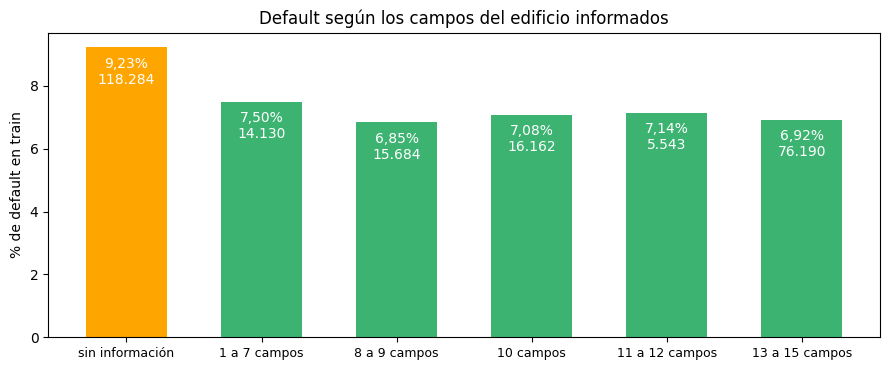

In [13]:
def rango(t):
    desde, hasta = int(t.left) + 1, int(t.right)
    return f"{desde} campos" if desde == hasta else f"{desde} a {hasta} campos"

con_info = train[train["HAS_BUILDING_INFO"].eq(1)]
edificio = pd.concat([
    train.loc[train["HAS_BUILDING_INFO"].eq(0), "TARGET"].agg(["mean", "size"]).to_frame("sin información").T,
    con_info.groupby(tramos(con_info["BUILDING_INFO_COUNT"]), observed=True)["TARGET"].agg(["mean", "size"]).rename(index=rango),
])
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(edificio.index.astype(str), edificio["mean"] * 100, color=[COLOR_NULO] + [COLOR_PRESENTE] * (len(edificio) - 1), width=0.6)
for x, (tasa, n) in enumerate(zip(edificio["mean"] * 100, edificio["size"])):
    etiqueta = f"{tasa:.2f}%".replace(".", ",") + f"\n{n:,.0f}".replace(",", ".")
    ax.text(x, tasa - 0.3, etiqueta, ha="center", va="top", color="white")
ax.set(ylabel="% de default en train", title="Default según los campos del edificio informados")
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()
plt.show()

In [14]:
informe_solo_vivas(train, prev).round(4)

,n,iv_sin_presencia,incremental_vivas_sobre_actual,llega
PREV_FUTURE_DUE_MAX,118400,0.0116,NaN,NaN
PREV_FUTURE_DUE_VIVAS,85565,0.0082,0.0067,False


In [15]:
ext3 = informe_incremental_ext3(train)
ext3.round(4)

,pearson_ext3,n,iv_dentro_de_su_tabla,incremental_sobre_ext3,llega
feature,,,,,
BUREAU_CREDITS_PER_YEAR,-0.4214,210875,0.0901,0.0240,True
BUREAU_DAYS_CREDIT_MAX,-0.3896,210875,0.0838,0.0311,True
BUREAU_ACTIVE_COUNT,-0.3888,210875,0.0453,0.0075,False
BUREAU_DAYS_CREDIT_UPDATE_FLAG,-0.3481,210874,0.0187,0.0136,False
BB_MONTHS_SINCE_LAST_DPD_REL,-0.3149,24841,0.0587,0.0300,True
BB_RECENT_DPD_FLAG_REL,-0.2992,73767,0.0504,0.0084,False
BB_OVERDUE_UNION,-0.2681,73767,0.0374,0.0118,False
BB_ANY_DPD_FLAG,-0.2370,73767,0.0282,0.0115,False
BUREAU_DAYS_CREDIT_MIN,-0.2263,210875,0.0739,0.0281,True


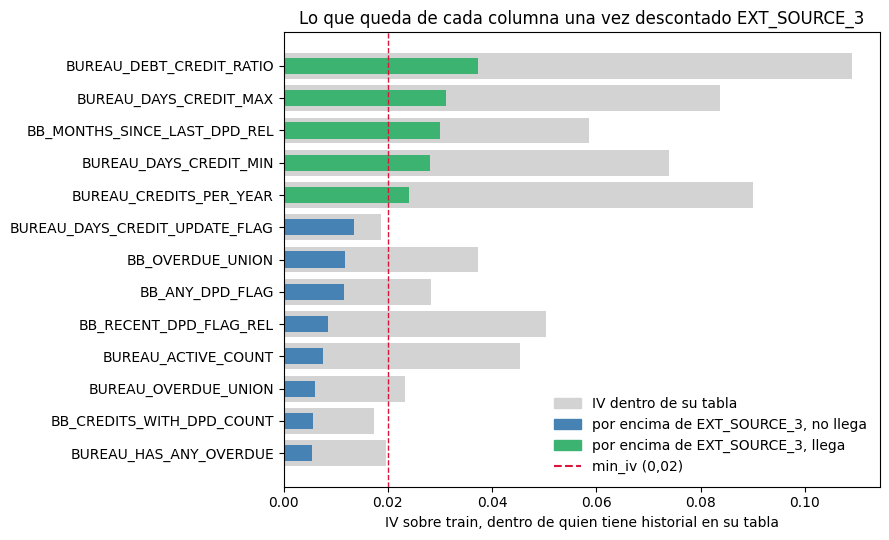

In [16]:
orden = ext3.sort_values("incremental_sobre_ext3").index
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(orden, ext3.loc[orden, "iv_dentro_de_su_tabla"], color="lightgrey")
ax.barh(orden, ext3.loc[orden, "incremental_sobre_ext3"], height=0.5, color=ext3.loc[orden, "llega"].map({True: COLOR_PRESENTE, False: "steelblue"}))
ax.axvline(min_iv, color="crimson", ls="--", lw=1)
ax.set(xlabel="IV sobre train, dentro de quien tiene historial en su tabla", title="Lo que queda de cada columna una vez descontado EXT_SOURCE_3")
ax.legend(
    handles=[Patch(color="lightgrey", label="IV dentro de su tabla"), Patch(color="steelblue", label="por encima de EXT_SOURCE_3, no llega"),
             Patch(color=COLOR_PRESENTE, label="por encima de EXT_SOURCE_3, llega"), plt.Line2D([], [], color="crimson", ls="--", label=min_iv_texto)],
    loc="lower right", frameon=False,
)
plt.tight_layout()
plt.show()

Cinco decisiones esperaban a tener el IV medido, y en ninguna ha acabado entrando una columna nueva.

`BUREAU_HAS_CURRENT_OVERDUE` (0,0099 de IV sin presencia): la mora activa se puede leer de la foto del crédito o de la suma de lo vencido, y ambas coinciden en 0,0099 sobre los 210.875 clientes con historial (2.688 y 2.687 marcados). Como el IV no decide, decide la construcción. Me quedo con la foto, que no pierde al cliente cuya única mora activa está en otra moneda.

La mora de `bureau` en tres niveles (incremento de 0,0014): esperaba que separar la mora reportada a cero de la que nunca se reportó aportara algo sobre la unión. Los dos niveles sin mora quedan en 0,59 pp (6,79% en 90.085 clientes frente a 7,38% en 62.863), lejos del 9,55% de quienes tienen mora. Los tres niveles aumentan el IV de 0,0234 a 0,0247, un incremento de 0,0014, así que no construyo la columna y se mantiene la unión.

`BUILDING_INFO_COUNT` (0,00015 de incremento respecto de `HAS_BUILDING_INFO`): confirma la sospecha. Quien no tiene ningún dato del edificio presenta un 9,23% de default (118.284 clientes), y entre quienes sí tienen alguno, la tasa se mantiene plana, de 6,85% a 7,50%, tenga 1 campo o 15. Todo su margen de 0,0212 era la señal de la bandera. Sale el conteo y queda en `HAS_BUILDING_INFO`.

`PREV_FUTURE_DUE_MAX` (0,0116): lee el fin previsto de cada solicitud aunque ya esté cerrada. Contando solo las vivas, el IV baja a 0,0082 sobre 85.565 clientes, y lo que aporta por encima de la actual se queda en 0,0067. Sigue como está.

Por último, el solapamiento con `EXT_SOURCE_3`. Como es un score de buró, esperaba que absorbiera buena parte de lo que indican las columnas `bureau` y `bureau_balance`. Trece se mueven con él con una correlación de al menos 0,20 en valor absoluto, hasta -0,4214 en `BUREAU_CREDITS_PER_YEAR`. Solo cinco conservan 0,02 de IV por encima del score: `BUREAU_DEBT_CREDIT_RATIO` (0,0373, de 0,1090 en su tabla), `BUREAU_DAYS_CREDIT_MAX` (0,0311), `BB_MONTHS_SINCE_LAST_DPD_REL` (0,0300), `BUREAU_DAYS_CREDIT_MIN` (0,0281) y `BUREAU_CREDITS_PER_YEAR` (0,0240). Las que más pierden son las de mora y actividad: `BB_RECENT_DPD_FLAG_REL` pasa de 0,0504 a 0,0084 y `BUREAU_ACTIVE_COUNT` de 0,0453 a 0,0075, lo que indica que el score ya incorpora la mora del buró. Las ocho restantes aún no salen; solo quedan marcadas. El corte final se decide con la redundancia de por delante. Entre la mejor de las marcadas (0,0136, `BUREAU_DAYS_CREDIT_UPDATE_FLAG`) y la peor de las que llegan (0,0240) hay un hueco limpio, así que la decisión no depende de un solo decimal.

### 4. Cuando dos columnas dicen lo mismo

In [17]:
pares = pares_redundantes(train)
redundancia = pares[["tipo", "r", "r_bin", "n", "zona"]].join(informe_redundancia(train, pares)[["iv_a", "iv_b", "inc_a", "inc_b", "queda"]])
print(f"{len(redundancia)} pares; se quedan las dos en {redundancia['queda'].map(len).eq(2).sum()}, sale una en {redundancia['queda'].map(len).eq(1).sum()}")
redundancia.round(4)

15 pares; se quedan las dos en 7, sale una en 8


tipo       r  \
a                                 b                                             
BB_MANY_CREDITS_FLAG              BUREAU_COUNT_COLA                FF  0.9981   
BB_MONTHS_REPORTED                BUREAU_CLOSED_COUNT              MM  0.6227   
                                  BUREAU_LOAN_COUNT                MM  0.6932   
BB_MONTHS_TOTAL                   BUREAU_CLOSED_COUNT              MM  0.8037   
                                  BUREAU_DAYS_CREDIT_MIN           MM -0.6047   
                                  BUREAU_LOAN_COUNT                MM  0.7989   
BB_OVERDUE_UNION                  BUREAU_HAS_ANY_OVERDUE           FF  0.8502   
                                  BUREAU_MAX_OVERDUE_EVER          FM  0.0945   
                                  BUREAU_OVERDUE_UNION             FF  0.8667   
BUREAU_ACTIVE_COUNT               BUREAU_DAYS_CREDIT_UPDATE_FLAG   FM  0.4355   
                                  BUREAU_LOAN_COUNT                MM  0.6919   
BUREAU_ANNUITY_ACTIVE_RATIO       HAS_BUREAU_BALANCE               FM  0.6152   
BUREAU_CREDITS_WITH_ANNUITY_COUNT HAS_BUREAU_BALANCE               FM  0.5373   
FLAG_EXT_SOURCE_3_NULL            HAS_BUREAU_HISTORY               FF -0.7903   
HAS_BUREAU_HISTORY                HAS_BUREAU_INFO                  FF  0.9667   

                                                                   r_bin  \
a                                 b                                        
BB_MANY_CREDITS_FLAG              BUREAU_COUNT_COLA                  NaN   
BB_MONTHS_REPORTED                BUREAU_CLOSED_COUNT                NaN   
                                  BUREAU_LOAN_COUNT                  NaN   
BB_MONTHS_TOTAL                   BUREAU_CLOSED_COUNT                NaN   
                                  BUREAU_DAYS_CREDIT_MIN             NaN   
                                  BUREAU_LOAN_COUNT                  NaN   
BB_OVERDUE_UNION                  BUREAU_HAS_ANY_OVERDUE             NaN   
                                  BUREAU_MAX_OVERDUE_EVER         0.8936   
                                  BUREAU_OVERDUE_UNION               NaN   
BUREAU_ACTIVE_COUNT               BUREAU_DAYS_CREDIT_UPDATE_FLAG  0.7106   
                                  BUREAU_LOAN_COUNT                  NaN   
BUREAU_ANNUITY_ACTIVE_RATIO       HAS_BUREAU_BALANCE              0.7420   
BUREAU_CREDITS_WITH_ANNUITY_COUNT HAS_BUREAU_BALANCE              0.7420   
FLAG_EXT_SOURCE_3_NULL            HAS_BUREAU_HISTORY                 NaN   
HAS_BUREAU_HISTORY                HAS_BUREAU_INFO                    NaN   

                                                                       n  \
a                                 b                                        
BB_MANY_CREDITS_FLAG              BUREAU_COUNT_COLA                73767   
BB_MONTHS_REPORTED                BUREAU_CLOSED_COUNT              73767   
                                  BUREAU_LOAN_COUNT                73767   
BB_MONTHS_TOTAL                   BUREAU_CLOSED_COUNT              73767   
                                  BUREAU_DAYS_CREDIT_MIN           73767   
                                  BUREAU_LOAN_COUNT                73767   
BB_OVERDUE_UNION                  BUREAU_HAS_ANY_OVERDUE          210875   
                                  BUREAU_MAX_OVERDUE_EVER         147167   
                                  BUREAU_OVERDUE_UNION            210875   
BUREAU_ACTIVE_COUNT               BUREAU_DAYS_CREDIT_UPDATE_FLAG  210874   
                                  BUREAU_LOAN_COUNT               210875   
BUREAU_ANNUITY_ACTIVE_RATIO       HAS_BUREAU_BALANCE              210875   
BUREAU_CREDITS_WITH_ANNUITY_COUNT HAS_BUREAU_BALANCE              210875   
FLAG_EXT_SOURCE_3_NULL            HAS_BUREAU_HISTORY              245993   
HAS_BUREAU_HISTORY                HAS_BUREAU_INFO                 245993   

                                                                        zona  \
a                    

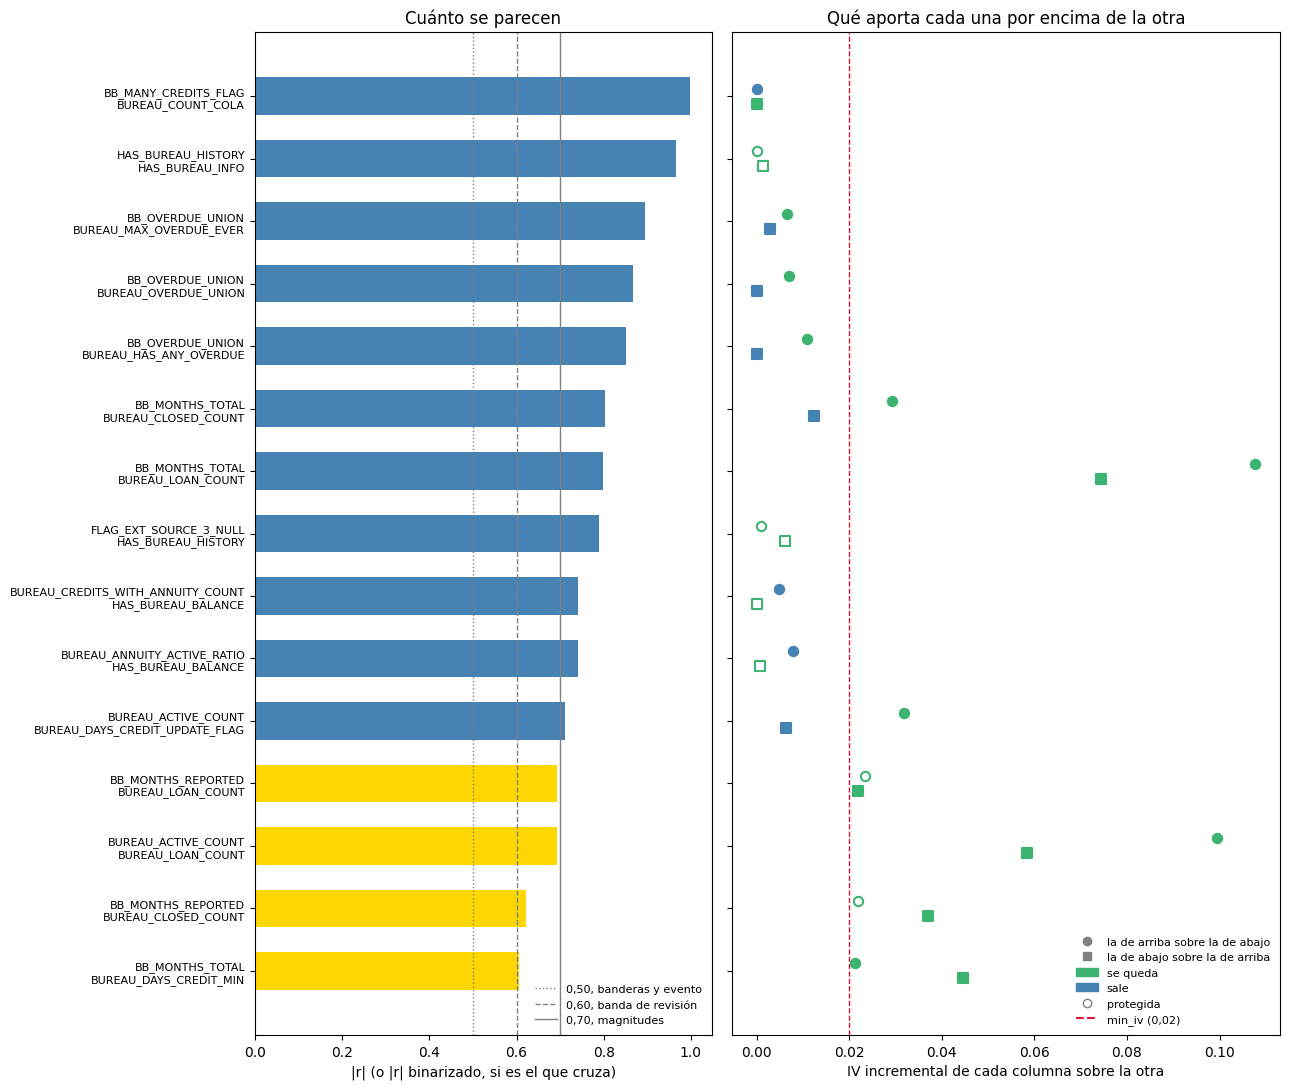

In [18]:
protegidas = columnas_protegidas()
fuerza = pd.concat([redundancia["r"].abs(), redundancia["r_bin"].abs()], axis=1).max(axis=1)
orden = fuerza.sort_values().index
etiquetas = [f"{a}\n{b}" for a, b in orden]
y = range(len(orden))

fig, (izq, der) = plt.subplots(1, 2, figsize=(13, 11), sharey=True, gridspec_kw={"width_ratios": [1, 1.2]})
izq.barh(y, fuerza[orden], color=redundancia.loc[orden, "zona"].map({"por encima": "steelblue", "banda": "gold"}), height=0.6)
umbrales_r = [
    (valor("redundancia_cramer"), ":", "banderas y evento"),
    (valor("banda_revision_pearson"), "--", "banda de revisión"),
    (valor("redundancia_pearson"), "-", "magnitudes"),
]
for umbral, estilo, texto in umbrales_r:
    izq.axvline(umbral, color="grey", ls=estilo, lw=1, label=f"{umbral:.2f}, {texto}".replace(".", ","))
izq.set(yticks=list(y), yticklabels=etiquetas, xlabel="|r| (o |r| binarizado, si es el que cruza)", title="Cuánto se parecen")
izq.legend(loc="lower right", frameon=False, fontsize=8)
izq.tick_params(axis="y", labelsize=8)

for fila, (a, b) in zip(y, orden):
    queda = redundancia.loc[(a, b), "queda"]
    for columna, inc, marca, desplaza in [(a, redundancia.loc[(a, b), "inc_a"], "o", 0.12), (b, redundancia.loc[(a, b), "inc_b"], "s", -0.12)]:
        color = COLOR_PRESENTE if columna in queda else "steelblue"
        der.scatter(inc, fila + desplaza, marker=marca, s=45, color=color if columna not in protegidas else "white", edgecolors=color, linewidths=1.5)
der.axvline(min_iv, color="crimson", ls="--", lw=1)
der.set(xlabel="IV incremental de cada columna sobre la otra", title="Qué aporta cada una por encima de la otra")
der.legend(
    handles=[plt.Line2D([], [], marker="o", ls="", color="grey", label="la de arriba sobre la de abajo"),
             plt.Line2D([], [], marker="s", ls="", color="grey", label="la de abajo sobre la de arriba"),
             Patch(color=COLOR_PRESENTE, label="se queda"), Patch(color="steelblue", label="sale"),
             plt.Line2D([], [], marker="o", ls="", markerfacecolor="white", markeredgecolor="grey", label="protegida"),
             plt.Line2D([], [], color="crimson", ls="--", label=min_iv_texto)],
    loc="lower right", frameon=False, fontsize=8,
)
plt.tight_layout()
plt.show()

Dentro de cada tabla, la redundancia ya estaba resuelta; entre tablas, nadie la había medido. Busqué pares con una correlación superior a 0,70 entre magnitudes y a 0,50 entre banderas, o entre una bandera y el hecho de que una magnitud sea mayor que cero. Revisé también la franja de 0,60 a 0,70 para no dejar pasar sin mirar lo que queda justo por debajo del umbral. Salen 15 pares, todos entre las tablas principales, `bureau` y `bureau_balance`. Para resolverlos no basta con que dos columnas se parezcan: miro si cada una aporta al menos 0,02 de IV por encima de la otra. Si lo aportan las dos, se quedan las dos. Si ninguna lo aporta, se queda la de más IV. Una columna protegida nunca sale.

El caso más claro es la misma cosa contada dos veces. `BB_MANY_CREDITS_FLAG` y `BUREAU_COUNT_COLA` (r = 0,9981) marcan la misma cola del conteo, fijada en 18 créditos en ambas tablas, y ninguna aporta nada sobre la otra (r = 0,0000). Queda la de `bureau`, por un IV apenas mayor (0,00222 frente a 0,00217). Con la mora pasa lo mismo: `BB_OVERDUE_UNION` se sitúa entre 0,8502 y 0,8936, a la par de las tres lecturas de mora de `bureau`; ninguna aporta más de 0,0109 respecto a ella, y queda por encima de ellas por más IV (0,0300 frente a 0,0234 de `BUREAU_OVERDUE_UNION`). Tiene sentido porque la unión de `bureau_balance` ya incorpora la mora reportada por `bureau`.

Lo contrario pasa con los conteos, que se parecen y, aun así, aportan cada uno lo suyo. `BB_MONTHS_TOTAL` y `BUREAU_LOAN_COUNT` pasan el umbral (0,7989), pero cada una suma por encima de la otra 0,1077 y 0,0745 de IV: con el umbral solo, una de las dos habría salido por nada. Lo mismo pasa en los cuatro pares de la franja de revisión, con `BUREAU_ACTIVE_COUNT` y `BUREAU_LOAN_COUNT` (0,6919; 0,0995 y 0,0583) como los más claros. Donde sí sale una es en `BB_MONTHS_TOTAL` frente a `BUREAU_CLOSED_COUNT` (0,8037): solo la primera aporta (0,0293 frente a 0,0123). Y `BUREAU_DAYS_CREDIT_UPDATE_FLAG` resulta ser casi lo mismo que tener algún crédito activo (0,7106 frente a `BUREAU_ACTIVE_COUNT` mayor que cero, aunque en bruto solo 0,4355), así que sale ella y se queda el conteo (0,0319 frente a 0,0063).

Las presencias mandan sobre quienes dependen de ellas. Las dos columnas de cuotas del buró se parecen a 0,7420 al tener un histórico mensual; no aportan nada por encima de `HAS_BUREAU_BALANCE` (0,0078 y 0,0048) y se eliminan. `HAS_BUREAU_HISTORY` se parece a `HAS_BUREAU_INFO` (0,9667) y a la ausencia de `EXT_SOURCE_3` (-0,7903): quien no aparece en el buró casi nunca tiene ese score. Las tres se quedan igualmente, porque cada una es la bandera que conserva el signo de la ausencia de las demás columnas.

En resumen, en 7 de los 15 pares se mantienen ambas columnas y en 8 solo una. Salen ocho columnas, todas de `bureau` salvo `BB_MANY_CREDITS_FLAG`, y tres de ellas ya venían marcadas por solaparse con `EXT_SOURCE_3`.

### 5. Qué acaba entrando al modelo

In [19]:
# el pipeline ajustado sobre train y el registro de selección
pipeline = joblib.load(ruta("models") / NOMBRE_FICHERO_PIPELINE)
registro = pd.read_csv(ruta("processed_data") / FICHEROS_DATOS["seleccion"], index_col="feature")
selector = pipeline.named_steps["seleccion"]

pd.Series({
    "columnas de capa 1, con identificador y TARGET": ensamblada.shape[1],
    "entran al pipeline": matriz_de_features(ensamblada).shape[1],
    "con los dos ratios posteriores a la winsorización": len(pipeline.named_steps["contrato"].get_feature_names_out()),
    "tras imputar y codificar": len(pipeline.named_steps["columnas"].get_feature_names_out()),
    "tras la selección": len(selector.quedan_),
}, name="columnas").to_frame()

,columnas
"columnas de capa 1, con identificador y TARGET",180
entran al pipeline,178
con los dos ratios posteriores a la winsorización,180
tras imputar y codificar,218
tras la selección,163


In [20]:
def tipo_de_decision(motivo):
    if motivo.startswith("IV "):
        return "no llega a min_iv" if "no llega" in motivo else "llega a min_iv"
    if motivo.startswith("protegida"):
        return "protegida"
    if motivo.startswith("sin decisión"):
        return "sin decisión, pasa"
    return "descarte fijo"

registro["decision"] = registro["motivo"].map(tipo_de_decision)
reparto = pd.crosstab(registro["tabla"], registro["decision"], margins=True, margins_name="total")
reparto

decision,descarte fijo,llega a min_iv,no llega a min_iv,protegida,"sin decisión, pasa",total
tabla,,,,,,
application_train,8,3,11,2,77,101
bureau,13,2,6,2,7,30
bureau_balance,11,4,0,1,7,23
previous_application,0,1,5,4,16,26
total,32,10,22,9,107,180


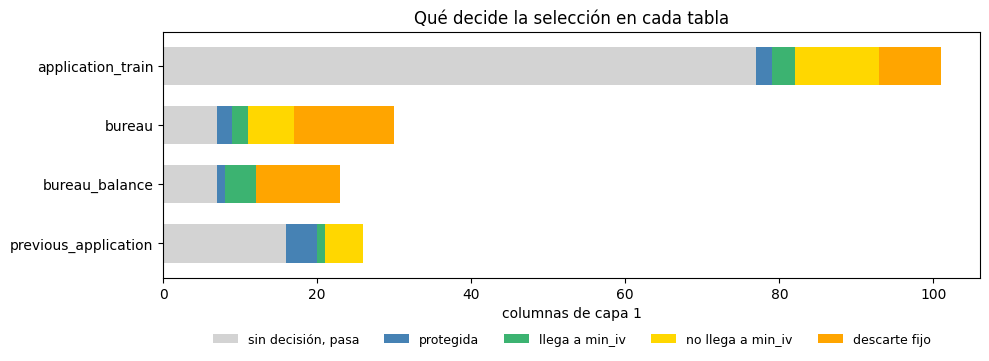

In [21]:
colores = {"sin decisión, pasa": "lightgrey", "protegida": "steelblue", "llega a min_iv": COLOR_PRESENTE,
           "no llega a min_iv": "gold", "descarte fijo": COLOR_NULO}
fig, ax = plt.subplots(figsize=(10, 3.8))
reparto.drop(index="total", columns="total")[list(colores)].iloc[::-1].plot.barh(stacked=True, color=list(colores.values()), ax=ax, width=0.65)
ax.set(xlabel="columnas de capa 1", ylabel="", title="Qué decide la selección en cada tabla")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=5, frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

In [22]:
# la lectura sin presencia de la sección de IV, frente a la que usa el selector, dentro de la población de su tabla
cobertura_train = train[list(presencia.values())].mean().set_axis(list(presencia))
dilucion = iv.loc[iv["iv_sin_presencia"].notna(), ["iv_lectura"]].assign(
    dentro=lambda d: d.index.map(selector.iv_),
    tabla=lambda d: d.index.map(registro["tabla"]),
)
dilucion.round(4)

,iv_lectura,dentro,tabla
feature,,,
HAS_BUREAU_FINANCIAL_DETAIL,0.0005,0.0005,bureau
HAS_BEEN_PROLONGED,0.0009,0.0010,bureau
BUREAU_DAYS_CREDIT_ENDDATE_MAX,0.0282,0.0293,bureau
BUREAU_ANNUITY_ACTIVE_RATIO,0.0078,0.0091,bureau
BUREAU_CREDIT_TYPE_NUNIQUE,0.0001,0.0002,bureau
BB_MANY_CREDITS_FLAG,0.0007,0.0022,bureau_balance
BB_MONTHS_TOTAL,0.0124,0.0413,bureau_balance
BB_DPD_MONTHS_COUNT,0.0076,0.0253,bureau_balance
BB_CREDITS_WITH_DPD_COUNT,0.0052,0.0044,bureau_balance


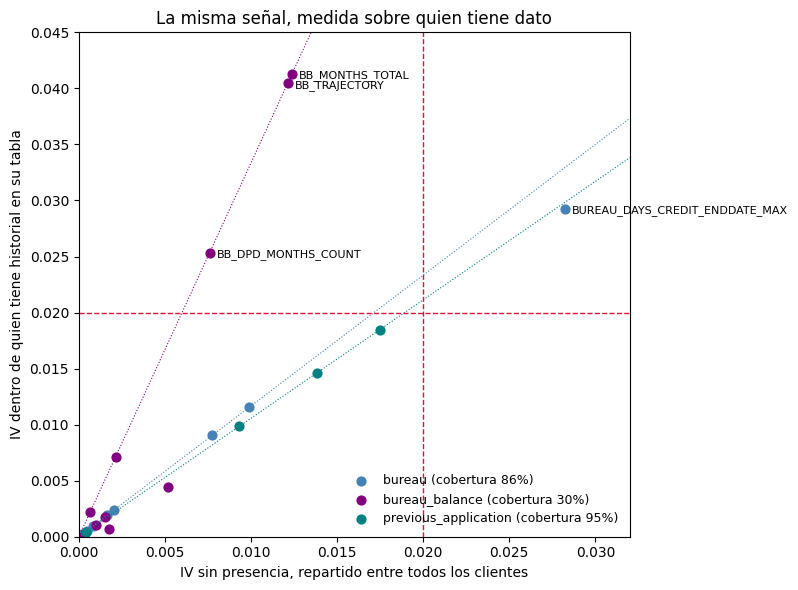

In [23]:
colores_tabla = {"bureau": "steelblue", "bureau_balance": "purple", "previous_application": "teal"}
fig, ax = plt.subplots(figsize=(8, 6))
recta = np.linspace(0, 0.032, 50)
for tabla, color in colores_tabla.items():
    puntos = dilucion[dilucion["tabla"].eq(tabla)]
    ax.scatter(puntos["iv_lectura"], puntos["dentro"], color=color, s=40, label=f"{tabla} (cobertura {cobertura_train[tabla]:.0%})")
    ax.plot(recta, recta / cobertura_train[tabla], color=color, lw=0.8, ls=":")
for nombre in dilucion.index[dilucion["dentro"] >= min_iv]:
    ax.annotate(nombre, (dilucion.loc[nombre, "iv_lectura"], dilucion.loc[nombre, "dentro"]), fontsize=8, xytext=(5, -3), textcoords="offset points")
ax.axhline(min_iv, color="crimson", ls="--", lw=1)
ax.axvline(min_iv, color="crimson", ls="--", lw=1)
ax.set(xlim=(0, 0.032), ylim=(0, 0.045), xlabel="IV sin presencia, repartido entre todos los clientes",
       ylabel="IV dentro de quien tiene historial en su tabla", title="La misma señal, medida sobre quien tiene dato")
ax.legend(loc="lower right", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

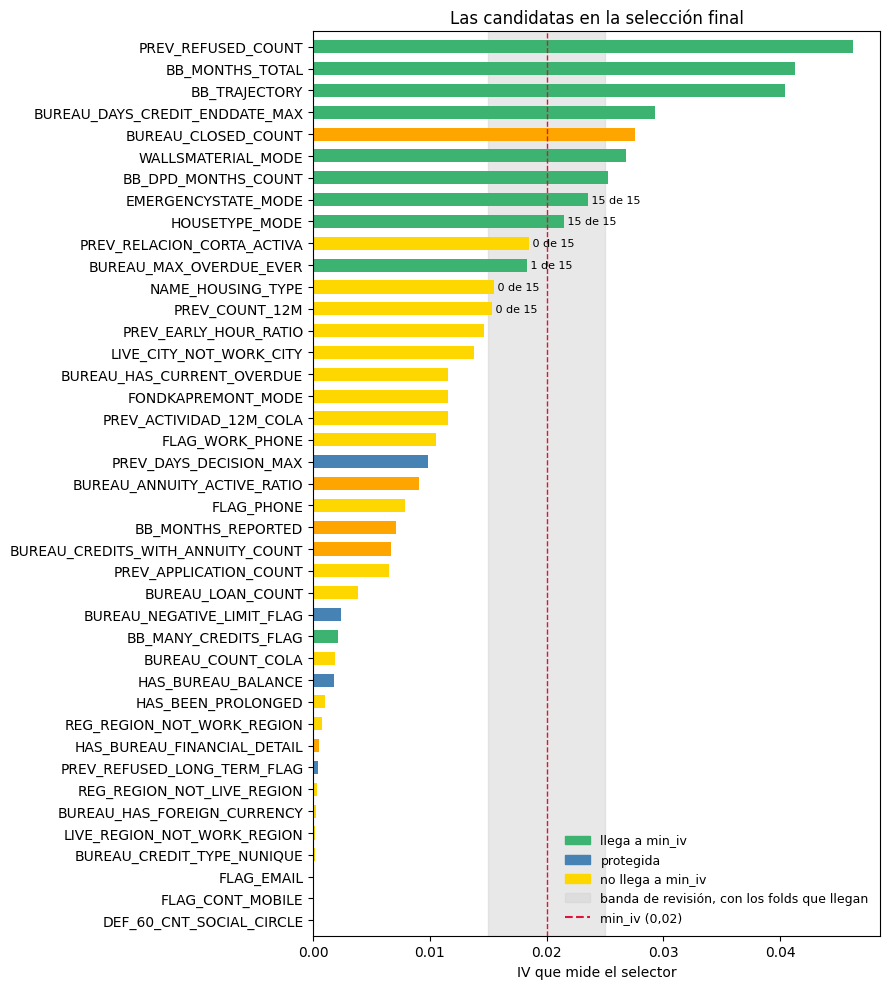

In [24]:
candidatas = pd.Series({o: selector.iv_[o] for o in selector.candidatas}, name="iv").sort_values()
suelo, techo = valor("banda_revision_iv_suelo"), valor("banda_revision_iv_techo")
fig, ax = plt.subplots(figsize=(9, 10))
ax.axvspan(suelo, techo, color="lightgrey", alpha=0.5)
ax.barh(candidatas.index, candidatas, color=registro.loc[candidatas.index, "decision"].map(colores), height=0.6)
for nombre, valor_iv in candidatas.items():
    if registro.loc[nombre, "en_banda"]:
        ax.text(valor_iv, nombre, f" {registro.loc[nombre, 'folds']:.0f} de 15", va="center", fontsize=8)
ax.axvline(min_iv, color="crimson", ls="--", lw=1)
ax.set(xlabel="IV que mide el selector", title="Las candidatas en la selección final")
ax.legend(
    handles=[Patch(color=colores[d], label=d) for d in ("llega a min_iv", "protegida", "no llega a min_iv")]
    + [Patch(color="lightgrey", alpha=0.5, label="banda de revisión, con los folds que llegan"),
       plt.Line2D([], [], color="crimson", ls="--", label=min_iv_texto)],
    loc="lower right", frameon=False, fontsize=9,
)
ax.margins(y=0.01)
plt.tight_layout()
plt.show()

In [25]:
registro.loc[registro["en_banda"], ["tabla", "iv", "folds", "decision", "queda"]].sort_values("iv", ascending=False)

,tabla,iv,folds,decision,queda
feature,,,,,
EMERGENCYSTATE_MODE,application_train,0.023591,15.0,llega a min_iv,True
HOUSETYPE_MODE,application_train,0.021523,15.0,llega a min_iv,True
PREV_RELACION_CORTA_ACTIVA,previous_application,0.018472,0.0,no llega a min_iv,False
BUREAU_MAX_OVERDUE_EVER,bureau,0.018347,1.0,llega a min_iv,False
NAME_HOUSING_TYPE,application_train,0.015508,0.0,no llega a min_iv,False
PREV_COUNT_12M,previous_application,0.015333,0.0,no llega a min_iv,False


Las 180 columnas de la matriz (178 sin el identificador y el TARGET, y otra vez 180 con los dos ratios que se calculan después de winsorizar) se convierten en 218 al imputar y codificar, y la selección las deja en 163. La mayoría no pasa por ninguna decisión: 107 entran tal cual y 20 están protegidas (una de ellas, condicionada a que siga habiendo algo que proteger, hoy deja de estarlo). Otras 21 salen por motivos ya definidos antes de revisar este IV: su receta, una decisión ya tomada sobre su efecto, el solapamiento con `EXT_SOURCE_3` o la pérdida de su par en la redundancia entre tablas cuando la columna que gana sigue en la matriz. El IV decide sobre las 32 restantes y entran 8: `BUREAU_CLOSED_COUNT` llega a su propio 0,0276, pero pierde frente a `BB_MONTHS_TOTAL`. El recorte cae donde se esperaba: `bureau` pierde 19 de sus 30 columnas y `bureau_balance` 10 de sus 23, frente a 5 de sus 26 en `previous_application` y 12 de sus 101 en la tabla principal.

La lectura del IV que decide aquí no es la de repartir la señal entre todos los clientes, sino la de quien tiene historial en esa tabla. Es la que corresponde a cómo el modelo recibe la columna: con el dato de quien lo tiene y con la bandera de presencia para el resto. La diferencia entre las dos radica en la cobertura. En `bureau` (86%) y `previous_application` (95%) apenas cambia nada, pero en `bureau_balance`, con datos de solo el 30% de los clientes, la señal se diluye más de tres veces. `BB_MONTHS_TOTAL` pasa de 0,0124 a 0,0413, `BB_TRAJECTORY` de 0,0121 a 0,0404 y `BB_DPD_MONTHS_COUNT` de 0,0076 a 0,0253; las tres entran.

Las 8 que llegan a 0,02 son `PREV_REFUSED_COUNT` (0,0463), las tres de `bureau_balance`, `BUREAU_DAYS_CREDIT_ENDDATE_MAX` (0,0293) y tres del bloque edificio: `WALLSMATERIAL_MODE` (0,0268), `EMERGENCYSTATE_MODE` (0,0236) y `HOUSETYPE_MODE` (0,0215). `PREV_REFUSED_COUNT` es la única de las cuatro columnas que su receta dejaba como simple denominador y que vuelve con su propia señal. Las otras tres no llegan, y entre ellas está `BUREAU_LOAN_COUNT` (0,0038): se quedaba en los dos pares de conteos que se parecían y aun así aportaban, pero con su propio IV no alcanza el corte. Por debajo de 0,02 quedan seis que están protegidas por su papel y no por su IV. `PREV_DAYS_DECISION_MAX` es la variable de control temporal. `HAS_BUREAU_BALANCE`, `BB_MONTHS_REPORTED` y `HAS_BUREAU_FINANCIAL_DETAIL` indican a qué clientes les falta el historial mensual o el detalle financiero del buró. Y las dos banderas raras se sostienen por el efecto que ya medí con su n.

Por último, la estabilidad del corte. Seis columnas caen entre 0,015 y 0,025 de IV, donde un cambio de muestra podría moverlas de lado, así que repetí la medición en 15 particiones del conjunto de entrenamiento. Las que están por encima de 0,02 siguen en 14 o 15 de las 15, y las que están por debajo llegan a 0 o 1. Ninguna cambia de lado, así que la selección no depende del azar de la partición. La única dentro de la banda que no se sostiene es `BUREAU_MAX_OVERDUE_EVER`, que solo aparece en 1 de los 15 folds: pierde su par de redundancia con `BB_OVERDUE_UNION`, que tampoco se sostiene, y, al juzgarse por su propio IV, no cruza el corte de forma estable.

### 6. Cuadrando las cifras con el EDA

In [26]:
reconciliacion = informe_reconciliacion(base, ensamblada, pipeline, registro)
print(f"cuadran {reconciliacion['cuadra'].sum()} de {len(reconciliacion)}")
reconciliacion.style.map(lambda cuadra: f"color: {'mediumseagreen' if cuadra else 'crimson'}", subset=["cuadra"])

cuadran 20 de 20


,tabla,medida,eda,esperada,pipeline,cuadra,nota
0,application_train,filas,307511,307492,307492,True,
1,application_train,columnas de la tabla principal,122,101,101,True,31 fuera y 10 nuevas
2,application_train,centinela de DAYS_EMPLOYED,55374,55374,55374,True,
3,bureau,con historial de buró,263491,263475,263475,True,
4,bureau,sin historial de buró,44020,44017,44017,True,
5,bureau,ratio de deuda no nulo,262408,255094,255094,True,limpieza y sumas sin cero de relleno
6,bureau_balance,con histórico mensual,92231,92220,92220,True,
7,bureau_balance,suma de BB_MONTHS_TOTAL,14701612,14700583,14700583,True,
8,bureau_balance,con mora alguna vez,31052,31048,31048,True,
9,bureau_balance,con denominador suficiente,83971,83960,83960,True,


Como cierre, contrasto las cifras de control de cada tabla con las que dejó el análisis exploratorio, y las 20 cuadran con lo esperado para la población de modelado. La diferencia entre las dos series es casi siempre la de los 19 clientes que la limpieza quita de la tabla principal (307.511 frente a 307.492), todos sin default. Por eso quedan 263.475 clientes con historial de buró frente a 263.491, 92.220 con historial mensual frente a 92.231 y 291.041 con previas frente a 291.057. La única que se mueve más es el ratio de deuda sobre crédito, que pasa de 262.408 clientes con dato a 255.094. Es un cambio buscado: además de la limpieza de los créditos, quien no tiene ninguna deuda reportada ya no recibe un ratio de 0, que se leería como que no debe nada, sino un hueco. La tabla principal pasa de 122 a 101 columnas, con 31 eliminadas y 10 nuevas. La matriz completa tiene 180, que se convierten en 218 al codificar y en 163 al final, con 8 de las 41 candidatas dentro y 6 columnas en la banda de revisión.